## Продуктовая аналитика БД доставки еды

Необходимо выявить ключевые факторы задержек доставки и предложить дашборд метрик для управления операционной эффективностью

In [1]:
#импорт библиотек
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#посмотрим на данные

df = pd.read_csv('food_delivery_orders.csv', sep=',', encoding = 'utf-8')

In [3]:
df.head()

,order_id,ordered_at,city,cuisine,weather_condition,traffic_level,courier_type,delivery_tier,order_value_usd,item_count,...,courier_distance_km,courier_rating,batch_size,active_orders_nearby,restaurant_backlog_orders,promised_delivery_minutes,actual_delivery_minutes,tip_rate,customer_rating,was_late
0,FDS-700000,2025-01-01T09:00:00,Seattle,indian,clear,medium,walker,standard,53.60,2,...,6.91,4.79,1,45,9,57.6,84.7,0.039,3.52,1
1,FDS-700001,2025-01-01T09:35:00,Atlanta,indian,storm,high,car,standard,30.53,5,...,6.88,4.69,1,40,0,62.9,108.3,0.155,3.08,1
2,FDS-700002,2025-01-01T10:10:00,Phoenix,salad,rain,low,car,standard,40.03,3,...,7.45,4.77,1,47,13,62.4,102.3,0.093,3.22,1
3,FDS-700003,2025-01-01T10:45:00,Chicago,thai,clear,high,bike,scheduled,25.13,1,...,4.01,4.48,2,36,10,42.4,78.7,0.108,3.21,1
4,FDS-700004,2025-01-01T11:20:00,Austin,sushi,rain,severe,scooter,standard,44.66,3,...,5.71,4.63,1,40,14,51.0,99.3,0.146,2.86,1


In [4]:
df.shape

(1800, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   1800 non-null   str    
 1   ordered_at                 1800 non-null   str    
 2   city                       1800 non-null   str    
 3   cuisine                    1800 non-null   str    
 4   weather_condition          1800 non-null   str    
 5   traffic_level              1800 non-null   str    
 6   courier_type               1800 non-null   str    
 7   delivery_tier              1800 non-null   str    
 8   order_value_usd            1800 non-null   float64
 9   item_count                 1800 non-null   int64  
 10  prep_time_minutes          1800 non-null   int64  
 11  courier_distance_km        1800 non-null   float64
 12  courier_rating             1800 non-null   float64
 13  batch_size                 1800 non-null   int64  
 14  act

In [6]:
df.describe()

,order_value_usd,item_count,prep_time_minutes,courier_distance_km,courier_rating,batch_size,active_orders_nearby,restaurant_backlog_orders,promised_delivery_minutes,actual_delivery_minutes,tip_rate,customer_rating,was_late
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,28.122144,3.404444,23.155556,4.773617,4.679761,1.196667,41.800556,10.553889,47.970444,84.716500,0.106074,3.135300,0.984444
std,9.574633,1.568797,5.679040,2.106811,0.216360,0.429835,17.272196,5.868712,10.754683,17.191593,0.049054,0.427681,0.123782
min,9.000000,1.000000,6.000000,0.400000,3.990000,1.000000,8.000000,0.000000,18.000000,29.800000,0.020000,1.570000,0.000000
25%,21.465000,2.000000,19.000000,3.250000,4.530000,1.000000,30.000000,6.000000,40.675000,72.800000,0.072000,2.850000,1.000000
50%,28.005000,3.000000,23.000000,4.750000,4.690000,1.000000,42.000000,11.000000,48.050000,84.300000,0.104000,3.120000,1.000000
75%,34.352500,4.000000,27.000000,6.222500,4.850000,1.000000,54.000000,15.000000,55.425000,95.700000,0.140000,3.420000,1.000000
max,60.750000,9.000000,41.000000,11.810000,5.000000,4.000000,102.000000,27.000000,87.100000,142.300000,0.292000,4.840000,1.000000


In [7]:
''' 
Идентификаторы и временные метки
order_id - id заказа, ordered_at - время создания заказа
Характеристики заказа
city - город, cuisine -тип кухни, order_value_usd - стоимость заказа в $, item_count - количество позиций в заказе
Факторы окружающей среды
weather_condition - тип погоды, traffic_level - уровень пробок
Курьерские метрики
courier_type - тип курьера (передвижение), courier_distance_km - расстоение курьера до клиента, courier_rating - рейтинг курьера, 
batch_size - количество заказов курьера за 1 рейс
Ресторанные метрики
prep_time_minutes - время готовки заказа, restaurant_backlog_orders - количество заказов в очереди ресторана, 
active_orders_nearby - количество активных заказов рядом (Конкуренция курьеров)
Сроки и задержки
delivery_tier - тир заказа (премиум пользователь или нет), promised_delivery_minutes - обещанное время доставки,
actual_delivery_minutes - реальное время доставки, was_late - 1-опоздал, 0 - нет
Пост-доставка
tip_rat - процент чаевых, courier_rating - оценка курьера,  customer_rating - оценка заказа
'''

' \nИдентификаторы и временные метки\norder_id - id заказа, ordered_at - время создания заказа\nХарактеристики заказа\ncity - город, cuisine -тип кухни, order_value_usd - стоимость заказа в $, item_count - количество позиций в заказе\nФакторы окружающей среды\nweather_condition - тип погоды, traffic_level - уровень пробок\nКурьерские метрики\ncourier_type - тип курьера (передвижение), courier_distance_km - расстоение курьера до клиента, courier_rating - рейтинг курьера, \nbatch_size - количество заказов курьера за 1 рейс\nРесторанные метрики\nprep_time_minutes - время готовки заказа, restaurant_backlog_orders - количество заказов в очереди ресторана, \nactive_orders_nearby - количество активных заказов рядом (Конкуренция курьеров)\nСроки и задержки\ndelivery_tier - тир заказа (премиум пользователь или нет), promised_delivery_minutes - обещанное время доставки,\nactual_delivery_minutes - реальное время доставки, was_late - 1-опоздал, 0 - нет\nПост-доставка\ntip_rat - процент чаевых, cou

## 1. Исследовательский анализ 
- Распределение was_late (баланс классов)
- Выбросы в actual_delivery_minutes и promised_delivery_minutes
- Анализ смещения рейтинга
- Корреляции с целевой меткой was_late

In [8]:
# рассмотрим насколько часто курьеры опаздывают

was_late_count = df.was_late.value_counts(normalize = True)


([<matplotlib.patches.Wedge at 0x2367f6cdbe0>,
 [Text(-1.098686760397627, 0.05373455617168283, 'Опоздало'),
  Text(1.0986867394725348, -0.05373498401610039, 'Во время')],
 [Text(-0.5992836874896146, 0.029309757911826995, '98.4%'),
  Text(0.599283676075928, -0.029309991281509302, '1.6%')])

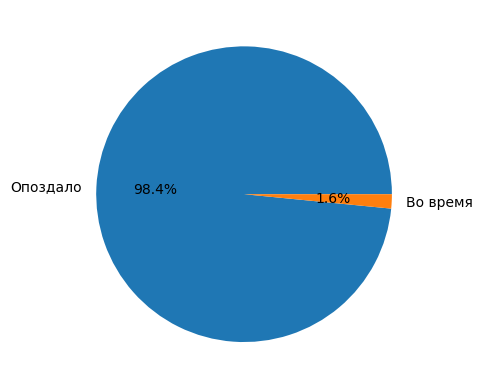

In [9]:
plt.pie(was_late_count.values, labels = ['Опоздало', 'Во время'], autopct = "%1.1f%%")

In [10]:
#найдем аномальные значения во времени доставки
sorted_df = df.sort_values('actual_delivery_minutes')
sorted_df['actual_delivery_minutes'].describe()

count    1800.000000
mean       84.716500
std        17.191593
min        29.800000
25%        72.800000
50%        84.300000
75%        95.700000
max       142.300000
Name: actual_delivery_minutes, dtype: float64

In [11]:
Q1 = sorted_df['actual_delivery_minutes'].quantile(0.25)
Q3 = sorted_df['actual_delivery_minutes'].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(22.900000000000006)

In [12]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['actual_delivery_minutes'] < lower_bound) | (df['actual_delivery_minutes'] > upper_bound)]
outliers

,order_id,ordered_at,city,cuisine,weather_condition,traffic_level,courier_type,delivery_tier,order_value_usd,item_count,...,courier_distance_km,courier_rating,batch_size,active_orders_nearby,restaurant_backlog_orders,promised_delivery_minutes,actual_delivery_minutes,tip_rate,customer_rating,was_late
95,FDS-700095,2025-01-03T16:25:00,Chicago,pizza,storm,medium,scooter,standard,24.94,1,...,7.85,4.31,2,55,19,63.0,134.1,0.078,3.04,1
116,FDS-700116,2025-01-04T04:40:00,Atlanta,thai,clear,medium,bike,standard,15.22,6,...,10.02,4.61,1,61,19,76.2,142.3,0.182,3.45,1
174,FDS-700174,2025-01-05T14:30:00,Seattle,burger,storm,high,bike,standard,25.12,5,...,8.20,4.69,1,31,12,69.6,139.0,0.037,2.69,1
243,FDS-700243,2025-01-07T06:45:00,Phoenix,mexican,rain,severe,bike,standard,38.47,2,...,8.29,4.61,2,60,20,68.0,135.7,0.056,3.13,1
480,FDS-700480,2025-01-13T01:00:00,Austin,mexican,heatwave,severe,car,standard,37.26,4,...,8.71,4.52,2,48,15,71.5,130.7,0.101,2.78,1
563,FDS-700563,2025-01-15T01:25:00,Austin,pizza,clear,low,scooter,standard,20.71,4,...,1.52,4.59,1,27,9,31.5,36.4,0.143,4.84,0
668,FDS-700668,2025-01-17T14:40:00,Austin,mexican,storm,severe,walker,standard,23.90,2,...,5.52,4.51,1,71,3,53.6,132.3,0.024,2.12,1
672,FDS-700672,2025-01-17T17:00:00,New York,salad,clear,medium,car,standard,13.99,1,...,2.53,4.81,1,17,5,29.3,35.2,0.182,4.13,0
680,FDS-700680,2025-01-17T21:40:00,Atlanta,burger,storm,high,walker,standard,28.29,4,...,6.33,4.59,2,74,19,57.3,136.9,0.093,2.20,1
802,FDS-700802,2025-01-20T20:50:00,Chicago,thai,clear,severe,car,standard,40.38,2,...,1.52,4.48,1,14,2,19.5,37.8,0.158,2.99,1


Посмотрев на получившиеся выбросы, понимаю, что ничего абсурдого и выбивающегося нет
Нормальный диапазон: от 38.45 до 130.05 минут
Найдено выбросов: 18 заказов из 1800 (1% данных)
Значит это не ошибки в записи, а реальный результат
продолжаем анализ

In [13]:
#анализ пропусков в courier_rating, customer_rating

In [14]:
missing_rate = df[['courier_rating', 'customer_rating']].isnull().sum()
missing_rate


courier_rating     0
customer_rating    0
dtype: int64

Пропусков в рейтинге не, все ставят оценки

In [15]:
rating_by_late = df.groupby(['was_late'], as_index = False)[['courier_rating','customer_rating']].mean()
rating_by_late

,was_late,courier_rating,customer_rating
0,0,4.653571,4.366786
1,1,4.680175,3.115841


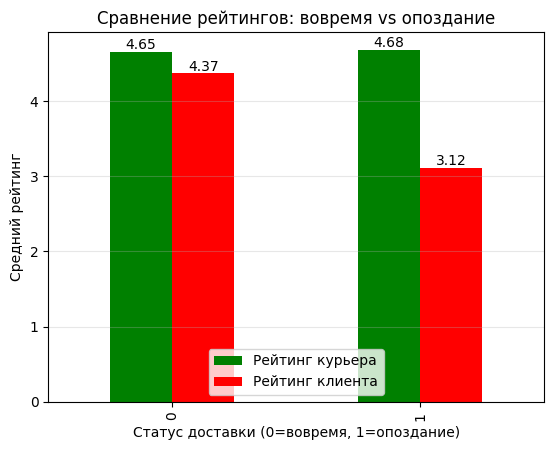

In [16]:
ax=rating_by_late[['courier_rating', 'customer_rating']].plot(kind='bar', color=['green', 'red'])
ax.set_title('Сравнение рейтингов: вовремя vs опоздание')
ax.set_xlabel('Статус доставки (0=вовремя, 1=опоздание)')
ax.set_ylabel('Средний рейтинг')
ax.legend(['Рейтинг курьера', 'Рейтинг клиента'], loc='lower center')
ax.grid(True, alpha=0.3, axis='y')
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')

Получается курьеры почти не страдают от опозданий, но клиенты занижают рейтинг самого заказа

In [17]:
#теперь в целом рассмотрим какие признаки связаны с опозданием

In [18]:
numeric_cols = ['order_value_usd', 'item_count', 'prep_time_minutes', 
                'courier_distance_km', 'courier_rating', 'batch_size',
                'active_orders_nearby', 'restaurant_backlog_orders', 
                'promised_delivery_minutes', 'actual_delivery_minutes', 
                'tip_rate', 'customer_rating', 'was_late']

correlation_matrix = df[numeric_cols].corr()
corr_with_late = correlation_matrix['was_late'].sort_values(ascending=False)

In [19]:
corr_with_late

was_late                     1.000000
actual_delivery_minutes      0.246235
active_orders_nearby         0.172744
restaurant_backlog_orders    0.110576
batch_size                   0.036636
promised_delivery_minutes    0.034478
courier_distance_km          0.033510
item_count                   0.026691
order_value_usd              0.024000
prep_time_minutes            0.020050
courier_rating               0.015220
tip_rate                    -0.065815
customer_rating             -0.362057
Name: was_late, dtype: float64

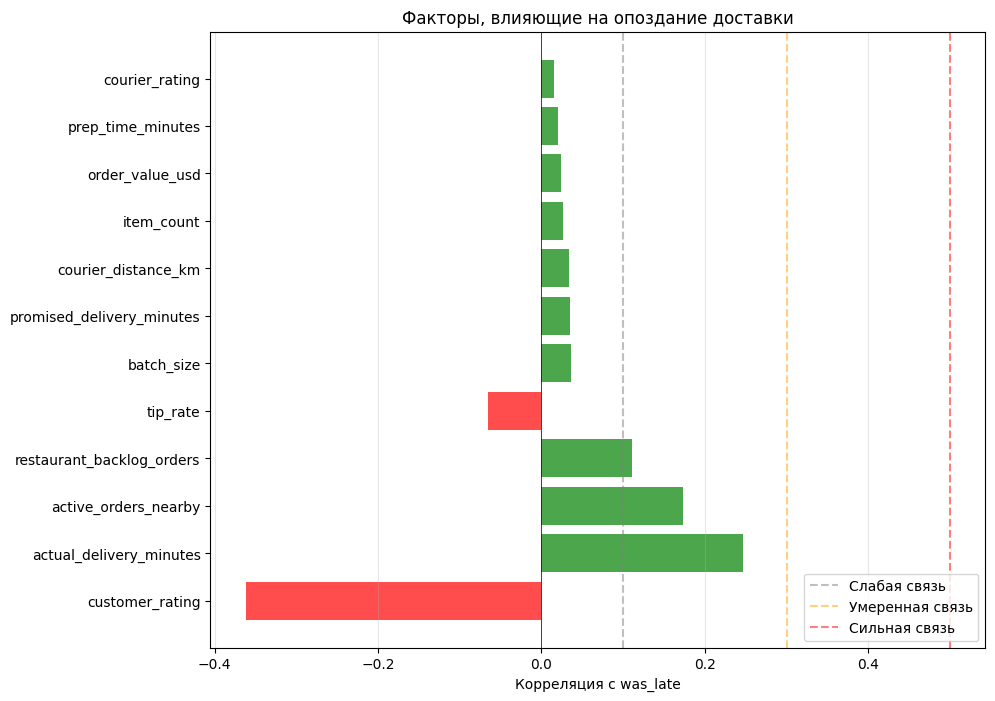

In [20]:
corr_without_target = corr_with_late.drop('was_late')

# Сортируем по абсолютной корреляции
corr_sorted = corr_without_target.abs().sort_values(ascending=False)
corr_without_target = corr_without_target[corr_sorted.index]

# Строим горизонтальный barplot
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['red' if x < 0 else 'green' for x in corr_without_target.values]
bars = ax.barh(corr_without_target.index, corr_without_target.values, color=colors, alpha=0.7)

ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='Слабая связь')
ax.axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='Умеренная связь')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Сильная связь')

ax.set_xlabel('Корреляция с was_late')
ax.set_title('Факторы, влияющие на опоздание доставки')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

Корреляционный анализ показал, что ни один фактор не имеет сильной линейной связи с опозданием (максимум |r|=0.36 для customer_rating). Это указывает на то, что задержки обусловлены взаимодействием факторов (например, высокий traffic_level + большой backlog ресторана)

## 2. Продуктовые метрики
- On-Time Performance = 1 - was_late_mean
- Перцентили delivery time по городам/кухням
- Медианная задержка = actual - promised (где was_late=1)
- Конверсия заказов с high tip_rate, была ли задержка?

In [21]:
#процент заказов доставленных вовремя
otp = (1 - df['was_late'].mean())*100
otp

np.float64(1.5555555555555545)

In [22]:
# OTP по городам
otp_by_city = 1 - df.groupby('city')['was_late'].mean()
print("\nOTP по городам:")
print(otp_by_city.sort_values(ascending=False))


OTP по городам:
city
Chicago     0.022508
Austin      0.021739
Seattle     0.020270
Phoenix     0.011321
New York    0.010101
Atlanta     0.006472
Name: was_late, dtype: float64


In [23]:
# OTP по кухням
otp_by_cuisine = 1 - df.groupby('cuisine')['was_late'].mean()
print("\nТоп-5 кухонь по OTP:")
print(otp_by_cuisine.nlargest(5))


Топ-5 кухонь по OTP:
cuisine
salad      0.022642
thai       0.020576
mexican    0.019231
burger     0.016260
indian     0.014925
Name: was_late, dtype: float64


In [24]:
print("\nХудшие 5 кухонь по OTP:")
print(otp_by_cuisine.nsmallest(5))


Худшие 5 кухонь по OTP:
cuisine
sushi      0.003759
pizza      0.011905
indian     0.014925
burger     0.016260
mexican    0.019231
Name: was_late, dtype: float64


In [25]:
# OTP по типу доставки
otp_by_tier = 1 - df.groupby('delivery_tier')['was_late'].mean()
print("\nOTP по типу доставки:")
print(otp_by_tier)


OTP по типу доставки:
delivery_tier
priority     0.013021
scheduled    0.011952
standard     0.017167
Name: was_late, dtype: float64


Что странного?
приоритетная доставка должна быть быстрее стандартной, но здесь она хуже
запланированная тоже хуже стандартной

In [26]:
# Проверьте, не перепутаны ли метки
#Сравнение promised по типу доставки:
df.groupby('delivery_tier')['promised_delivery_minutes'].mean()

delivery_tier
priority     44.250521
scheduled    49.843028
standard     48.793133
Name: promised_delivery_minutes, dtype: float64

In [27]:
#Сравнение actual по типу доставки:
df.groupby('delivery_tier')['actual_delivery_minutes'].mean()

delivery_tier
priority     81.528646
scheduled    86.425498
standard     85.399056
Name: actual_delivery_minutes, dtype: float64

In [28]:
#Сравнение разрыва:
df.groupby('delivery_tier').apply(lambda x: (x['actual_delivery_minutes'] - x['promised_delivery_minutes']).mean())

delivery_tier
priority     37.278125
scheduled    36.582470
standard     36.605923
dtype: float64

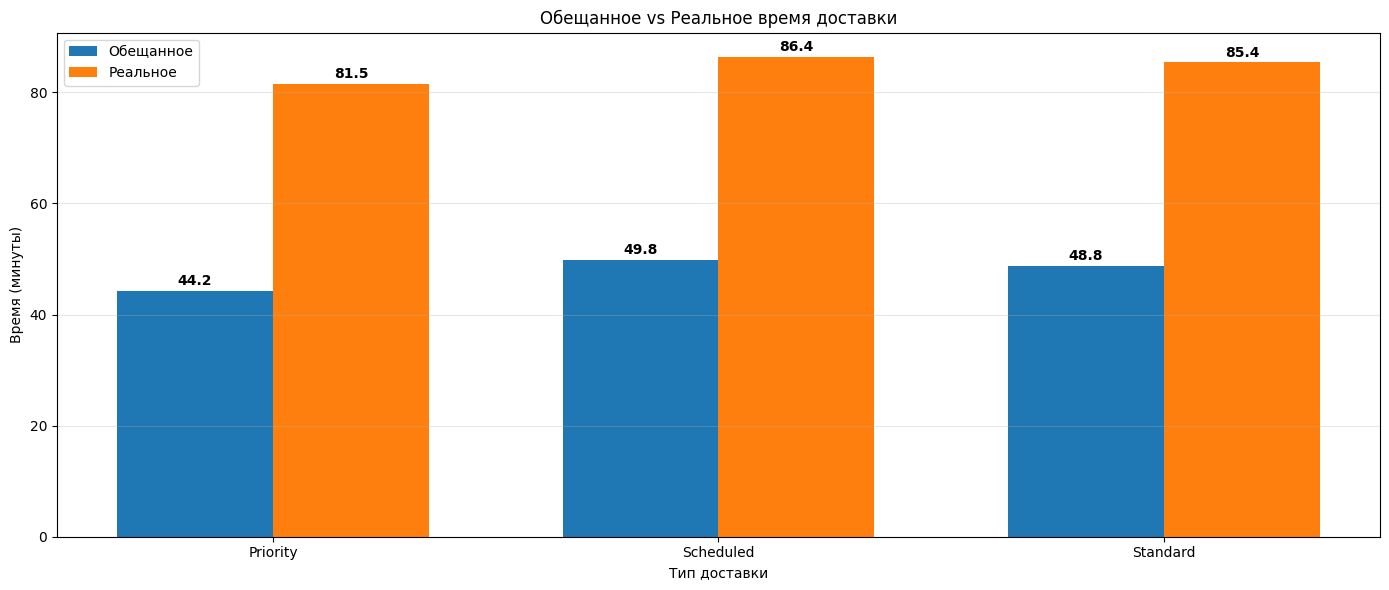

In [29]:
fig, axes = plt.subplots(figsize=(14, 6))

# Данные
tiers = ['Priority', 'Scheduled', 'Standard']
promised = [44.25, 49.84, 48.79]
actual = [81.53, 86.43, 85.40]

# График Сравнение promised vs actual
x = range(len(tiers))
width = 0.35

axes.bar([i - width/2 for i in x], promised, width, label='Обещанное')
axes.bar([i + width/2 for i in x], actual, width, label='Реальное')

axes.set_xlabel('Тип доставки')
axes.set_ylabel('Время (минуты)')
axes.set_title('Обещанное vs Реальное время доставки')
axes.set_xticks(x)
axes.set_xticklabels(tiers)
axes.legend()
axes.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i in range(3):
    axes.text(i - width/2, promised[i] + 1, f'{promised[i]:.1f}', ha='center', fontweight='bold')
    axes.text(i + width/2, actual[i] + 1, f'{actual[i]:.1f}', ha='center', fontweight='bold')


plt.tight_layout()
plt.show()

Все типы доставки имеют одинаковый разрыв (~37 минут)
Это значит, что проблема не в типе доставки, а в:
1. Алгоритме расчета promised (занижает на 37 мин)
2. Логистике (реальное время всегда на 37 мин больше)
3. Отсутствии учета внешних факторов (погода, пробки)

Перцентили delivery time по городам/кухням

In [30]:
# Общая статистика по actual_delivery_minutes
df['actual_delivery_minutes'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    1800.000000
mean       84.716500
std        17.191593
min        29.800000
50%        84.300000
75%        95.700000
90%       106.800000
95%       113.505000
99%       128.501000
max       142.300000
Name: actual_delivery_minutes, dtype: float64

Разница между P50 и P95 всего 29 минут — время доставки довольно стабильно

In [31]:
# Перцентили по городам
percentiles = [0.5, 0.75, 0.9, 0.95]
city_percentiles = df.groupby('city')['actual_delivery_minutes'].quantile(percentiles).unstack()
city_percentiles.columns = ['P50 (медиана)', 'P75', 'P90', 'P95']
print("\nВремя доставки по городам (минуты):")
print(city_percentiles.round(1))


Время доставки по городам (минуты):
          P50 (медиана)   P75    P90    P95
city                                       
Atlanta            84.3  96.9  108.5  114.6
Austin             82.7  94.5  108.2  114.2
Chicago            83.3  94.4  106.1  111.0
New York           85.0  96.2  105.2  113.9
Phoenix            85.5  96.7  105.4  112.7
Seattle            84.7  94.7  106.9  114.4


Во всех городах одинаковый разброс времени доставки

In [32]:
# Перцентили по кухням
cuisine_percentiles = df.groupby('cuisine')['actual_delivery_minutes'].quantile(percentiles).unstack()
cuisine_percentiles.columns = ['P50 (медиана)', 'P75', 'P90', 'P95']
print(cuisine_percentiles.nlargest(5, 'P95').round(1))

         P50 (медиана)   P75    P90    P95
cuisine                                   
mexican           85.2  98.5  109.3  116.6
thai              83.4  95.0  107.2  115.6
indian            84.8  95.8  108.3  115.3
sushi             83.2  95.3  107.6  114.1
burger            83.3  95.6  106.6  111.8


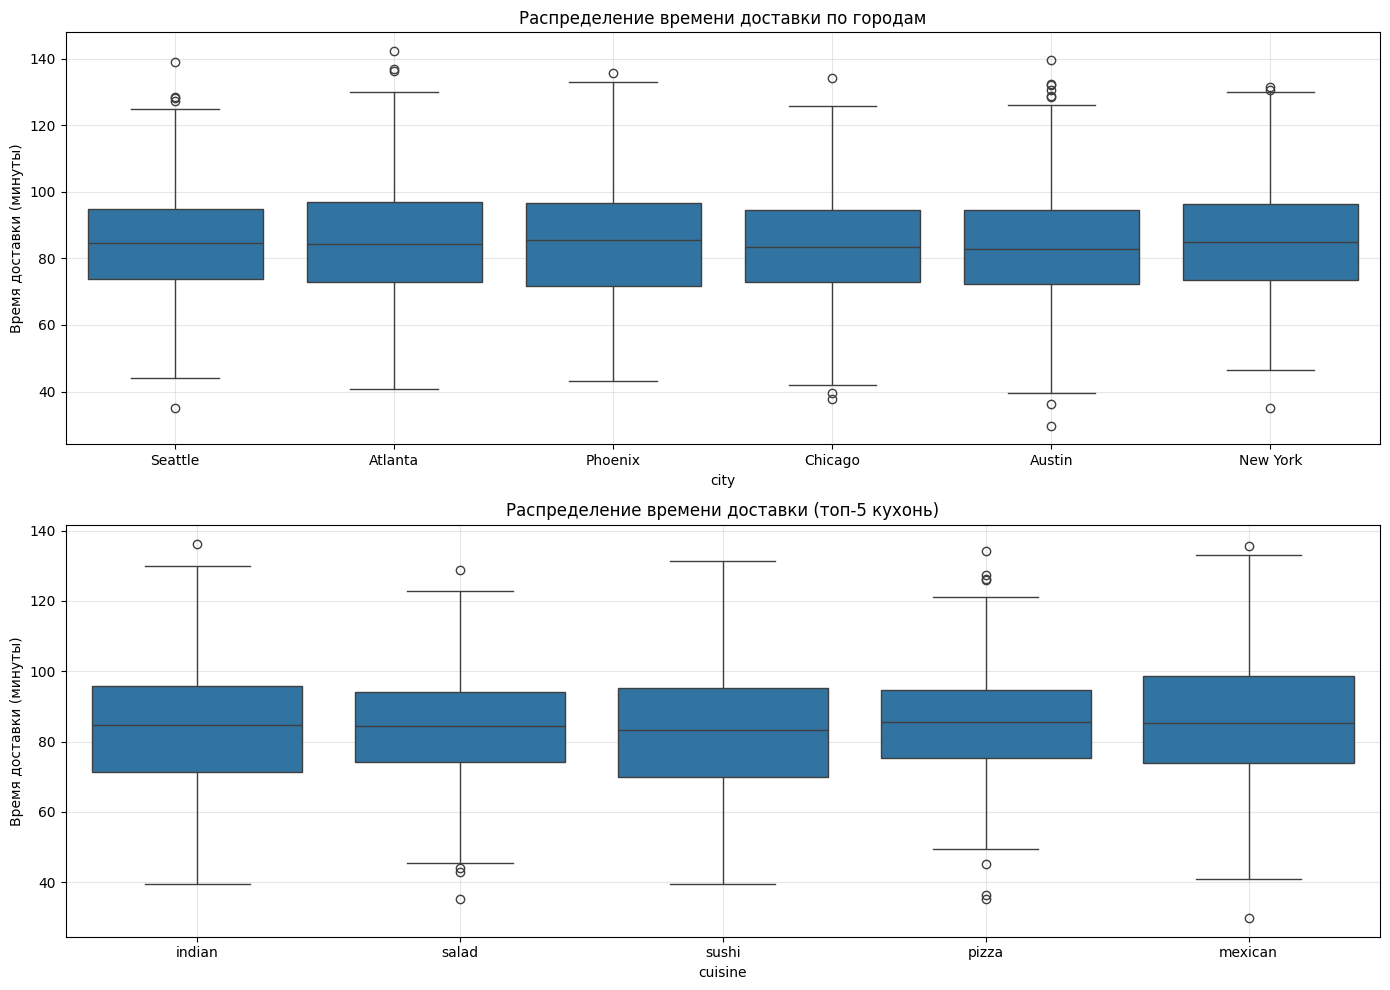

In [33]:
# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# График 1: Ящики с усами по городам
sns.boxplot(data=df, x='city', y='actual_delivery_minutes', ax=axes[0])
axes[0].set_title('Распределение времени доставки по городам')
axes[0].set_ylabel('Время доставки (минуты)')
axes[0].grid(True, alpha=0.3)

# График 2: Перцентили для топ-5 кухонь
top_cuisines = df['cuisine'].value_counts().nlargest(5).index
cuisine_data = df[df['cuisine'].isin(top_cuisines)]
sns.boxplot(data=cuisine_data, x='cuisine', y='actual_delivery_minutes', ax=axes[1])
axes[1].set_title('Распределение времени доставки (топ-5 кухонь)')
axes[1].set_ylabel('Время доставки (минуты)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# Создаем колонку с задержкой
df['delay_minutes'] = df['actual_delivery_minutes'] - df['promised_delivery_minutes']

In [35]:
# Фильтруем только опоздавшие заказы
 = df[df['was_late'] == 1]

In [36]:
# Медианная задержка
median_delay = late_orders['delay_minutes'].median()
mean_delay = late_orders['delay_minutes'].mean()
max_delay = late_orders['delay_minutes'].max()
min_delay = late_orders['delay_minutes'].min()

In [37]:
print(f"Количество опоздавших заказов: {len(late_orders)}")
print(f"Медианная задержка: {median_delay:.1f} минут")
print(f"Средняя задержка: {mean_delay:.1f} минут")
print(f"Минимальная задержка: {min_delay:.1f} минут")
print(f"Максимальная задержка: {max_delay:.1f} минут")

Количество опоздавших заказов: 1772
Медианная задержка: 36.8 минут
Средняя задержка: 37.2 минут
Минимальная задержка: 10.1 минут
Максимальная задержка: 87.9 минут


In [38]:
late_orders['delay_minutes'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

count    1772.000000
mean       37.231433
std        12.305567
min        10.100000
25%        28.600000
50%        36.750000
75%        45.325000
90%        53.390000
95%        58.245000
max        87.900000
Name: delay_minutes, dtype: float64

In [39]:
#Задержка по городам
city_delay = late_orders.groupby('city')['delay_minutes'].median().sort_values(ascending = False)
city_delay

city
New York    37.80
Phoenix     37.75
Chicago     36.65
Seattle     36.55
Atlanta     36.20
Austin      35.80
Name: delay_minutes, dtype: float64

In [40]:
#по кухням
cuisine_delay = late_orders.groupby('cuisine')['delay_minutes'].median().sort_values(ascending=False)
cuisine_delay

cuisine
mexican    37.90
salad      37.10
pizza      36.90
thai       36.70
sushi      36.60
indian     36.30
burger     35.75
Name: delay_minutes, dtype: float64

In [41]:
#тип курьера
courier_delay = late_orders.groupby('courier_type')['delay_minutes'].median().sort_values(ascending=False)
courier_delay

courier_type
walker     41.50
bike       36.75
car        36.60
scooter    35.25
Name: delay_minutes, dtype: float64

In [42]:
#уровень пробок
traffic_delay = late_orders.groupby('traffic_level')['delay_minutes'].median().sort_values(ascending=False)
traffic_delay

traffic_level
severe    47.00
high      39.05
medium    35.30
low       30.25
Name: delay_minutes, dtype: float64

In [43]:
#погода
weather_delay = late_orders.groupby('weather_condition')['delay_minutes'].median().sort_values(ascending=False)
weather_delay

weather_condition
storm       46.8
rain        41.0
heatwave    38.5
cold        35.5
clear       32.7
Name: delay_minutes, dtype: float64

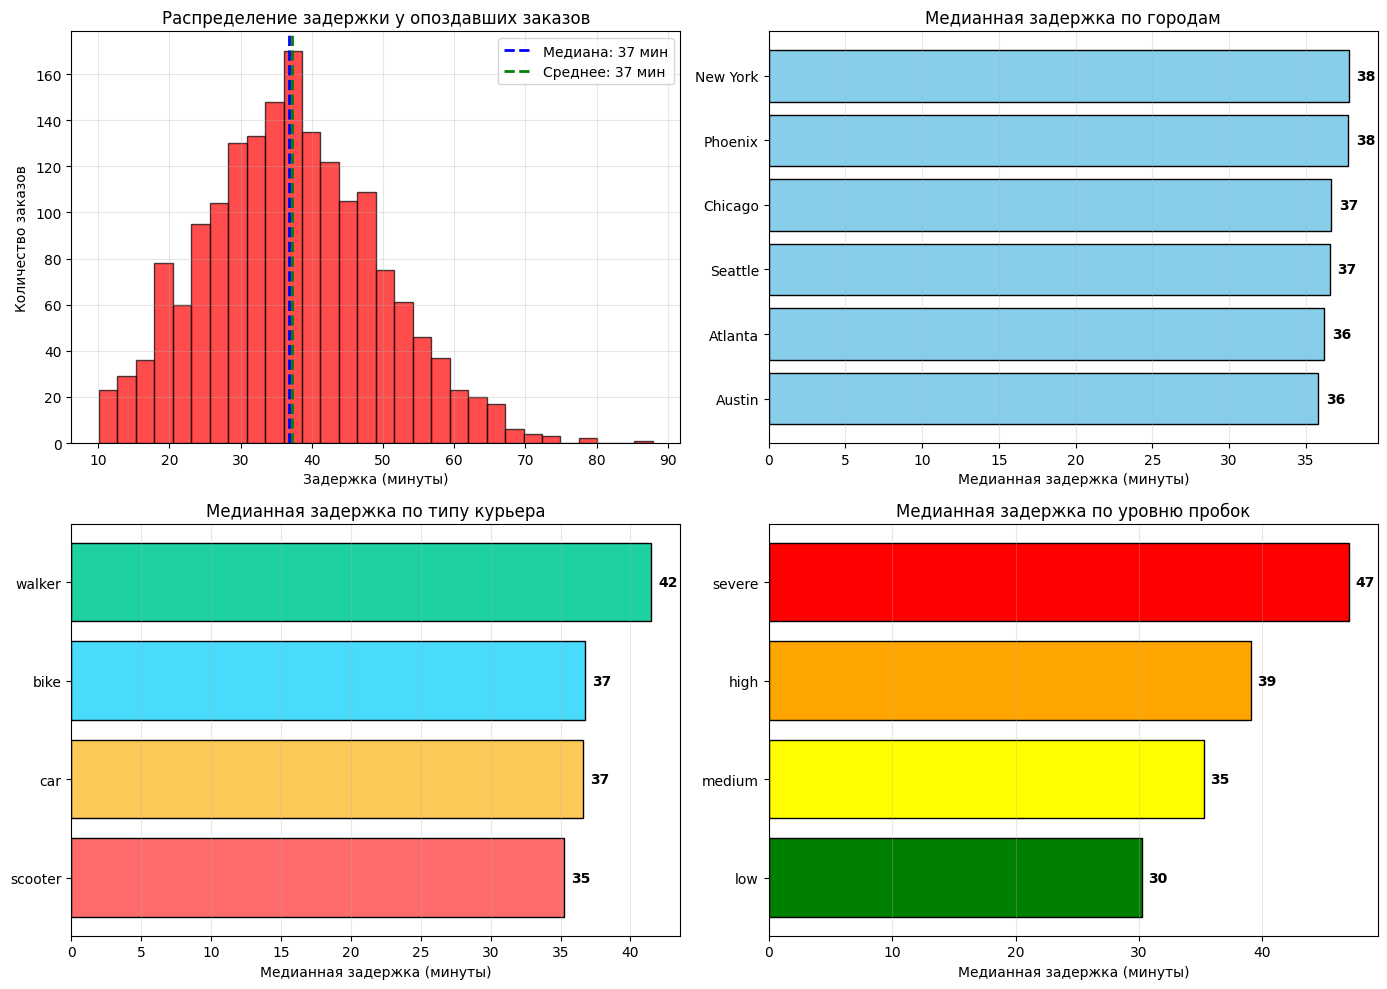

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Гистограмма задержки
axes[0, 0].hist(late_orders['delay_minutes'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(median_delay, color='blue', linestyle='--', linewidth=2, 
                   label=f'Медиана: {median_delay:.0f} мин')
axes[0, 0].axvline(mean_delay, color='green', linestyle='--', linewidth=2, 
                   label=f'Среднее: {mean_delay:.0f} мин')
axes[0, 0].set_xlabel('Задержка (минуты)')
axes[0, 0].set_ylabel('Количество заказов')
axes[0, 0].set_title('Распределение задержки у опоздавших заказов')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График 2: Задержка по городам
city_delay_sorted = city_delay.sort_values()
axes[0, 1].barh(city_delay_sorted.index, city_delay_sorted.values, color='skyblue', edgecolor='black')
axes[0, 1].set_xlabel('Медианная задержка (минуты)')
axes[0, 1].set_title('Медианная задержка по городам')
axes[0, 1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(city_delay_sorted.values):
    axes[0, 1].text(v + 0.5, i, f'{v:.0f}', va='center', fontweight='bold')

# График 3: Задержка по типу курьера
courier_delay_sorted = courier_delay.sort_values()
axes[1, 0].barh(courier_delay_sorted.index, courier_delay_sorted.values, 
                color=['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1'], edgecolor='black')
axes[1, 0].set_xlabel('Медианная задержка (минуты)')
axes[1, 0].set_title('Медианная задержка по типу курьера')
axes[1, 0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(courier_delay_sorted.values):
    axes[1, 0].text(v + 0.5, i, f'{v:.0f}', va='center', fontweight='bold')

# График 4: Задержка по уровню пробок
traffic_delay_sorted = traffic_delay.sort_values()
colors_traffic = {'low': 'green', 'medium': 'yellow', 'high': 'orange', 'severe': 'red'}
traffic_colors = [colors_traffic.get(x, 'gray') for x in traffic_delay_sorted.index]
axes[1, 1].barh(traffic_delay_sorted.index, traffic_delay_sorted.values, color=traffic_colors, edgecolor='black')
axes[1, 1].set_xlabel('Медианная задержка (минуты)')
axes[1, 1].set_title('Медианная задержка по уровню пробок')
axes[1, 1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(traffic_delay_sorted.values):
    axes[1, 1].text(v + 0.5, i, f'{v:.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Ключевые выводы:

1.  Типичная задержка = 37 минут  
   - Распределение симметричное, разброс небольшой  
   - Это системная проблема, а не случайные сбои

2.  Пробки — главный драйвер задержек  
   - От low до severe: +17 минут задержки  
   - При severe пробках задержка на 57% выше

3.  Тип курьера имеет значение  
   - Пешие: 42 мин (худшие)  
   - Самокаты: 35 мин (лучшие)  
   - Разрыв: 7 минут

4.  Город практически не влияет  
   - Разница между городами: всего 2 минуты  
   - Проблема глобальная, а не локальная

### Приоритетные рекомендации:

1.  Внедрить динамический promised с учетом пробок
2.  Оптимизировать типы курьеров
3.  Увеличить базовый promised на 20-25 минут
4.  Внедрить компенсации при задержке >45 минут

In [45]:
# Определяем порог high tip_rate (75-й перцентиль)
high_tip_threshold = df['tip_rate'].quantile(0.75)
high_tip_threshold

np.float64(0.14)

In [46]:
# Создаем категорию
df['tip_category'] = df['tip_rate'].apply(lambda x: 'high' if x >= high_tip_threshold else 'normal')

# Проверяем распределение
print(f"Всего заказов: {len(df)}")
print(f"Заказов с high tip_rate: {len(df[df['tip_category'] == 'high'])} ({len(df[df['tip_category'] == 'high'])/len(df):.1%})")
print(f"Заказов с normal tip_rate: {len(df[df['tip_category'] == 'normal'])} ({len(df[df['tip_category'] == 'normal'])/len(df):.1%})")

Всего заказов: 1800
Заказов с high tip_rate: 454 (25.2%)
Заказов с normal tip_rate: 1346 (74.8%)


In [47]:
# Считаем долю опозданий в каждой группе
tip_vs_late = df.groupby('tip_category')['was_late'].mean() * 100
tip_vs_late_counts = df.groupby('tip_category')['was_late'].count()


print(f"High tip_rate опоздания: {tip_vs_late['high']:.1f}%")
print(f"Normal tip_rate опоздания: {tip_vs_late['normal']:.1f}%")
print(f"Разница: {tip_vs_late['high'] - tip_vs_late['normal']:.1f}%")

High tip_rate опоздания: 96.9%
Normal tip_rate опоздания: 99.0%
Разница: -2.0%


In [48]:
# преобразуем время в datetime
df['ordered_at'] = pd.to_datetime(df['ordered_at'])

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   order_id                   1800 non-null   str           
 1   ordered_at                 1800 non-null   datetime64[us]
 2   city                       1800 non-null   str           
 3   cuisine                    1800 non-null   str           
 4   weather_condition          1800 non-null   str           
 5   traffic_level              1800 non-null   str           
 6   courier_type               1800 non-null   str           
 7   delivery_tier              1800 non-null   str           
 8   order_value_usd            1800 non-null   float64       
 9   item_count                 1800 non-null   int64         
 10  prep_time_minutes          1800 non-null   int64         
 11  courier_distance_km        1800 non-null   float64       
 12  courier_rating   

In [50]:
#извлечем время по одтельность (час, день недели, месяц)
df['hour'] = df['ordered_at'].dt.hour
df['weekday'] = df['ordered_at'].dt.day_name()
df['month'] = df['ordered_at'].dt.month

In [64]:
#создадим распределение по типу дня (утро, день, вечер, ночь)

def day_time(hour):
    if 5 <= hour < 12:
        return 'Morning (5-11)'
    elif 12 <= hour < 17:
        return 'Afternoon (12-16)'
    elif 17 <= hour < 21:
        return 'Evening (17-20)'
    else:
        return 'Night (21-4)'

df['day_time'] = df['hour'].apply(day_time)
late_orders = df[df['was_late'] == 1].copy()

In [52]:
df['day_time'].value_counts().sort_index()

day_time
Afternoon (12-16)    376
Evening (17-20)      302
Morning (5-11)       522
Night (21-4)         600
Name: count, dtype: int64


OTP по времени суток:
day_time
Afternoon (12-16)    0.013298
Evening (17-20)      0.013245
Morning (5-11)       0.022989
Night (21-4)         0.011667
Name: was_late, dtype: float64


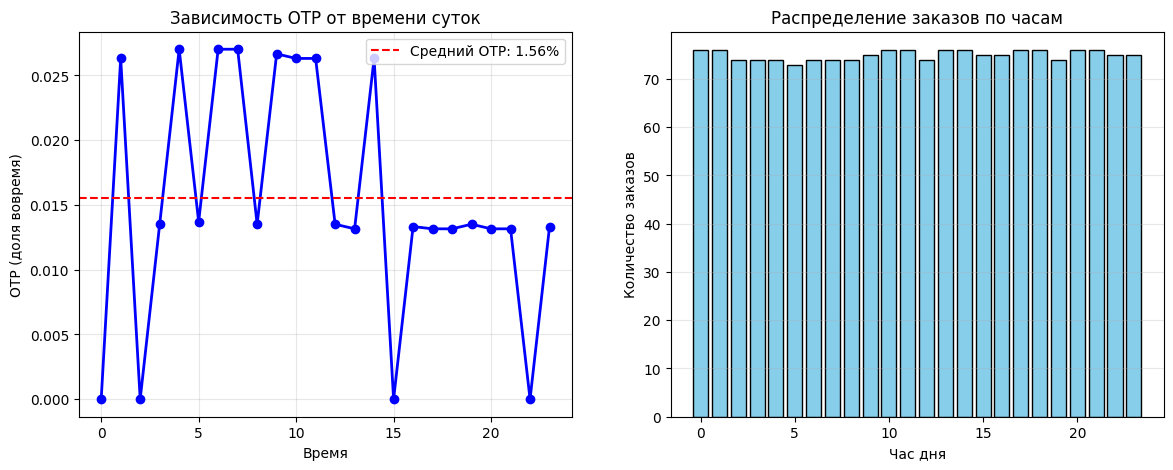

In [53]:
# OTP по часам
otp_by_hour = 1 - df.groupby('hour')['was_late'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: OTP по часам
axes[0].plot(otp_by_hour.index, otp_by_hour.values, marker='o', color='blue', linewidth=2)
axes[0].set_xlabel('Время')
axes[0].set_ylabel('OTP (доля вовремя)')
axes[0].set_title('Зависимость OTP от времени суток')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=otp_by_hour.mean(), color='red', linestyle='--', label=f'Средний OTP: {otp_by_hour.mean():.2%}')
axes[0].legend()

# График 2: Количество заказов по часам
orders_by_hour = df['hour'].value_counts().sort_index()
axes[1].bar(orders_by_hour.index, orders_by_hour.values, color='skyblue', edgecolor='black')
axes[1].set_xlabel('Час дня')
axes[1].set_ylabel('Количество заказов')
axes[1].set_title('Распределение заказов по часам')
axes[1].grid(True, alpha=0.3, axis='y')



print("\nOTP по времени суток:")
print(1 - df.groupby('day_time')['was_late'].mean())

### Когортный анализ по дням недели

In [65]:
# Порядок дней недели
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# OTP по дням недели
otp_by_day = 1 - df.groupby('weekday')['was_late'].mean()
otp_by_day = otp_by_day.reindex(day_order)

# Медианная задержка по дням недели
delay_by_day = late_orders.groupby('weekday')['delay_minutes'].median()
delay_by_day = delay_by_day.reindex(day_order)

# Количество заказов по дням недели
orders_by_day = df['weekday'].value_counts().reindex(day_order)

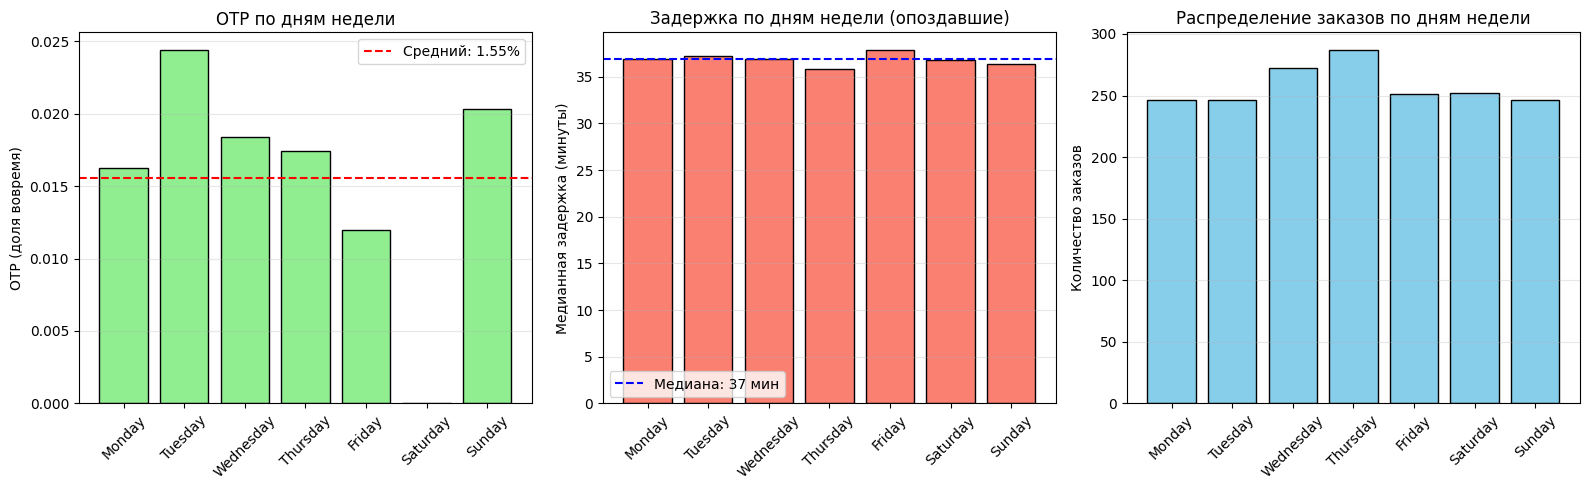

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# График 1: OTP по дням недели
axes[0].bar(otp_by_day.index, otp_by_day.values, color='lightgreen', edgecolor='black')
axes[0].set_ylabel('OTP (доля вовремя)')
axes[0].set_title('OTP по дням недели')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=otp_by_day.mean(), color='red', linestyle='--', label=f'Средний: {otp_by_day.mean():.2%}')
axes[0].legend()

# График 2: Медианная задержка по дням недели
axes[1].bar(delay_by_day.index, delay_by_day.values, color='salmon', edgecolor='black')
axes[1].set_ylabel('Медианная задержка (минуты)')
axes[1].set_title('Задержка по дням недели (опоздавшие)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=delay_by_day.median(), color='blue', linestyle='--', label=f'Медиана: {delay_by_day.median():.0f} мин')
axes[1].legend()

# График 3: Количество заказов по дням недели
axes[2].bar(orders_by_day.index, orders_by_day.values, color='skyblue', edgecolor='black')
axes[2].set_ylabel('Количество заказов')
axes[2].set_title('Распределение заказов по дням недели')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [72]:
summary_days = pd.DataFrame({
    'OTP': otp_by_day,
    'Медианная задержка (мин)': delay_by_day,
    'Количество заказов': orders_by_day
})
print(summary_days.round(3))

             OTP  Медианная задержка (мин)  Количество заказов
weekday                                                       
Monday     0.016                     36.85                 246
Tuesday    0.024                     37.25                 246
Wednesday  0.018                     36.90                 272
Thursday   0.017                     35.85                 287
Friday     0.012                     37.85                 251
Saturday   0.000                     36.80                 252
Sunday     0.020                     36.40                 246



📊 OTP по типу курьера и batch_size:
batch_size         1       2    3    4
courier_type                          
bike          0.0153  0.0000  0.0  NaN
car           0.0217  0.0062  0.0  0.0
scooter       0.0209  0.0152  0.0  0.0
walker        0.0000  0.0000  0.0  NaN


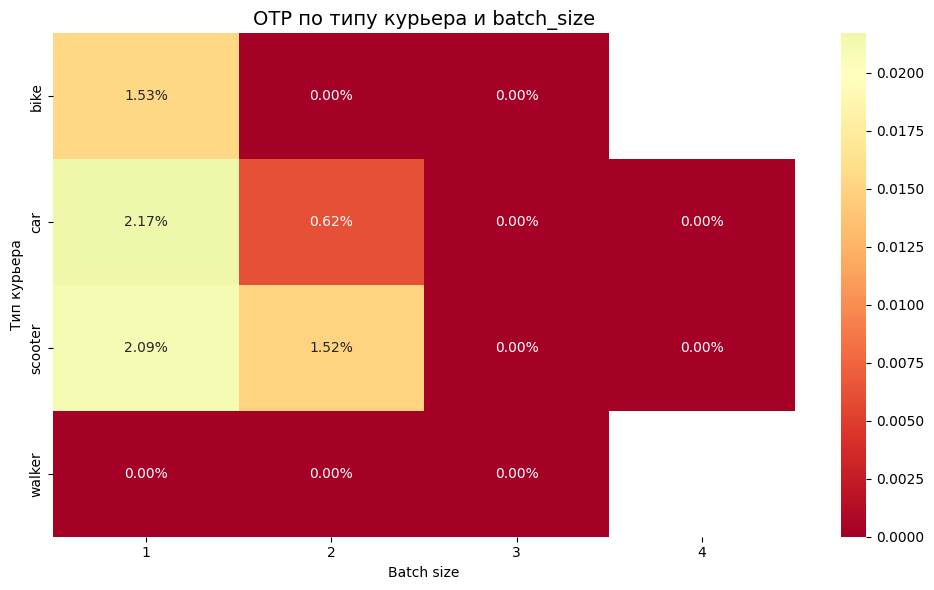


📊 Медианная задержка по типу курьера и batch_size:
batch_size       1     2     3     4
courier_type                        
bike          36.4  38.1  20.4   NaN
car           35.7  38.4  41.4  46.3
scooter       35.2  34.9  37.1  17.2
walker        41.2  42.8  60.5   NaN


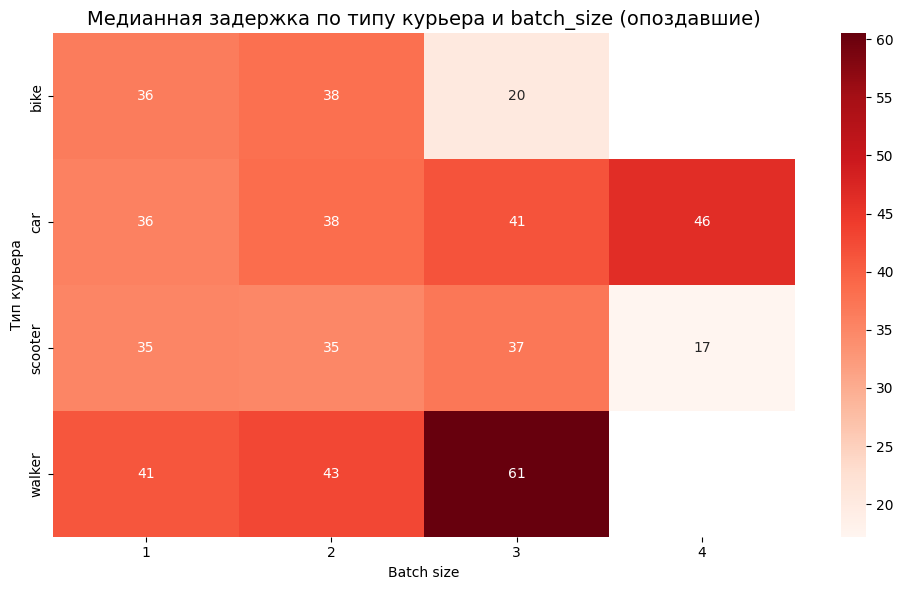

In [69]:
# Сводная таблица: OTP по типу курьера и batch_size
otp_courier_batch = 1 - df.groupby(['courier_type', 'batch_size'])['was_late'].mean().unstack()

print("\n📊 OTP по типу курьера и batch_size:")
print(otp_courier_batch.round(4))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(otp_courier_batch, annot=True, fmt='.2%', cmap='RdYlGn', center=0.02, ax=ax)
ax.set_title('OTP по типу курьера и batch_size', fontsize=14)
ax.set_xlabel('Batch size')
ax.set_ylabel('Тип курьера')
plt.tight_layout()
plt.show()

# Медианная задержка по типу курьера и batch_size
delay_courier_batch = late_orders.groupby(['courier_type', 'batch_size'])['delay_minutes'].median().unstack()

print("\n📊 Медианная задержка по типу курьера и batch_size:")
print(delay_courier_batch.round(1))

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(delay_courier_batch, annot=True, fmt='.0f', cmap='Reds', ax=ax)
ax.set_title('Медианная задержка по типу курьера и batch_size (опоздавшие)', fontsize=14)
ax.set_xlabel('Batch size')
ax.set_ylabel('Тип курьера')
plt.tight_layout()
plt.show()


OTP по времени суток и типу курьера:
courier_type    bike     car  scooter  walker
weekday                                      
Friday        0.0000  0.0268   0.0000     0.0
Monday        0.0600  0.0082   0.0000     0.0
Saturday      0.0000  0.0000   0.0000     0.0
Sunday        0.0182  0.0254   0.0208     0.0
Thursday      0.0000  0.0153   0.0517     0.0
Tuesday       0.0000  0.0312   0.0426     0.0
Wednesday     0.0161  0.0250   0.0159     0.0


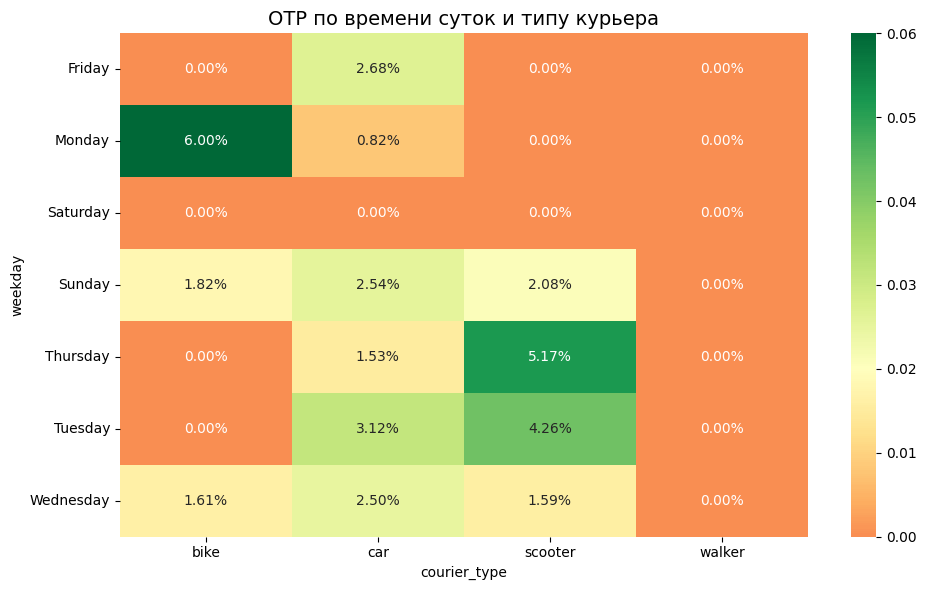


 OTP по погоде и типу курьера:
courier_type         bike     car  scooter  walker
weather_condition                                 
clear              0.0222  0.0312   0.0318     0.0
cold               0.0263  0.0215   0.0278     0.0
heatwave           0.0000  0.0128   0.0000     0.0
rain               0.0000  0.0055   0.0130     0.0
storm              0.0000  0.0000   0.0000     0.0


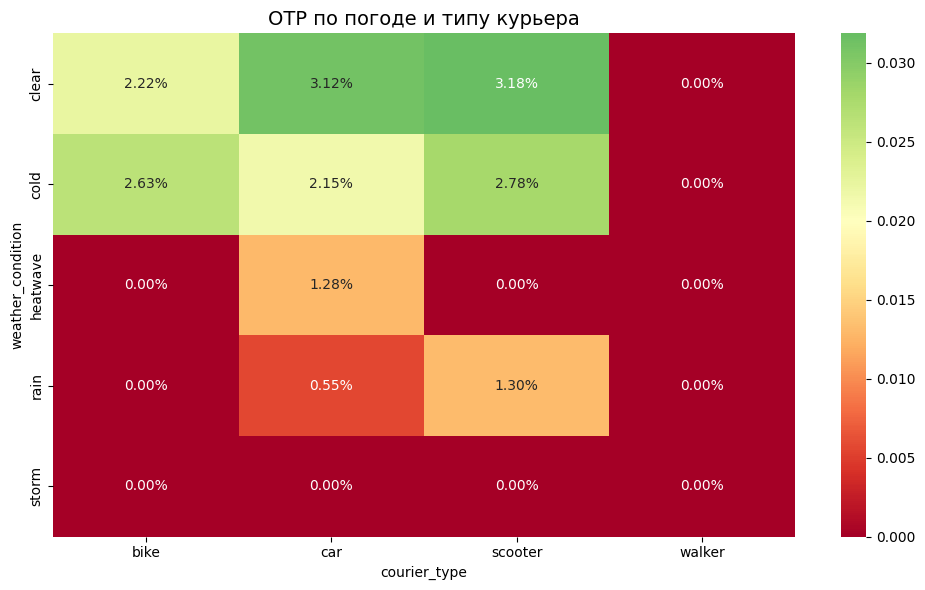

In [71]:
# Комбинация: время суток + тип курьера
time_courier_otp = 1 - df.groupby(['weekday', 'courier_type'])['was_late'].mean().unstack()

print("\nOTP по времени суток и типу курьера:")
print(time_courier_otp.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(time_courier_otp, annot=True, fmt='.2%', cmap='RdYlGn', center=0.02, ax=ax)
ax.set_title('OTP по времени суток и типу курьера', fontsize=14)
plt.tight_layout()
plt.show()

# Комбинация: погода + тип курьера
weather_courier_otp = 1 - df.groupby(['weather_condition', 'courier_type'])['was_late'].mean().unstack()

print("\n OTP по погоде и типу курьера:")
print(weather_courier_otp.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(weather_courier_otp, annot=True, fmt='.2%', cmap='RdYlGn', center=0.02, ax=ax)
ax.set_title('OTP по погоде и типу курьера', fontsize=14)
plt.tight_layout()
plt.show()

Рекомендации:
1. Заменить пеших курьеров на самокаты  
2. Ограничить количество заказов в одной доставке максимум 2  
3. Увеличить число курьеров в субботу 
4. Динамический promised в зависимости от погоды  
   - Дождь: +10 мин  
   - Буря: +20 мин
5. Машина + 1 заказ в доставке - использовать для приоритетных заказов  
   - Premium-клиенты, high tip_rate, экспресс-доставка

# A/B тестирования (основываясь на уже полученных данных)

1) A/B-тест: promised_delivery_minutes (низкое vs высокое обещание)
Разделим заказы на две группы:
- Группа A (низкий promised): обещанное время ≤ медианы
- Группа B (высокий promised): обещанное время > медианы

In [75]:
promised_median = df['promised_delivery_minutes'].median()
promised_median

np.float64(48.05)

In [83]:
# создаем группы
df['promised_group'] = df['promised_delivery_minutes'].apply(lambda x: 'A (low)' if x <= promised_median else 'B (high)')

In [84]:
df.tail(3)

,order_id,ordered_at,city,cuisine,weather_condition,traffic_level,courier_type,delivery_tier,order_value_usd,item_count,...,tip_rate,customer_rating,was_late,delay_minutes,tip_category,hour,weekday,month,day_time,promised_group
1797,FDS-701797,2025-02-14 01:15:00,Austin,thai,clear,high,walker,scheduled,17.63,5,...,0.160,3.13,1,41.8,high,1,Friday,2,Night (21-4),B (high)
1798,FDS-701798,2025-02-14 01:50:00,Seattle,pizza,clear,high,car,standard,36.24,5,...,0.132,2.79,1,26.8,normal,1,Friday,2,Night (21-4),A (low)
1799,FDS-701799,2025-02-14 02:25:00,Atlanta,burger,cold,high,car,standard,9.00,4,...,0.187,2.50,1,45.6,high,2,Friday,2,Night (21-4),B (high)


In [86]:
# Сравниваем метрики
promised_comparison = df.groupby('promised_group').agg({
    'was_late': ['mean', 'count'],
    'customer_rating': 'mean',
    'delay_minutes': 'mean',
    'actual_delivery_minutes': 'mean'
}).round(3)
promised_comparison

was_late       customer_rating delay_minutes  \
                   mean count            mean          mean   
promised_group                                                
A (low)           0.982   900           3.147        35.970   
B (high)          0.987   900           3.124        37.522   

               actual_delivery_minutes  
                                  mean  
promised_group                          
A (low)                         75.283  
B (high)                        94.150

In [88]:
# Статистическая значимость (для was_late)
from scipy.stats import chi2_contingency, ttest_ind

contingency_promised = pd.crosstab(df['promised_group'], df['was_late'])
chi2, p_promised, dof, expected = chi2_contingency(contingency_promised)

In [89]:
p_promised

np.float64(0.5677228253340428)

In [90]:
if p_promised < 0.05:
    print("Разница в опозданиях статистически значима (p < 0.05)")
else:
    print("Разница в опозданиях НЕ статистически значима (p > 0.05)")

Разница в опозданиях НЕ статистически значима (p > 0.05)


In [91]:
# t-test для customer_rating
group_a = df[df['promised_group'] == 'A (low promised)']['customer_rating']
group_b = df[df['promised_group'] == 'B (high promised)']['customer_rating']
t_stat, p_rating = ttest_ind(group_a, group_b)

C:\Users\tails\AppData\Local\Temp\ipykernel_6624\1061606308.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_stat, p_rating = ttest_ind(group_a, group_b)


In [93]:
p_rating

np.float64(nan)

In [94]:
if p_rating < 0.05:
    print("Разница в рейтинге статистически значима (p < 0.05)")
else:
    print("Разница в рейтинге НЕ статистически значима (p > 0.05)")

Разница в рейтинге НЕ статистически значима (p > 0.05)


In [98]:
from scipy.stats import mannwhitneyu

# Используем Mann-Whitney U test 
group_a_rating = df[df['promised_group'] == 'A (low)']['customer_rating']
group_b_rating = df[df['promised_group'] == 'B (high)']['customer_rating']

# Проверяем, есть ли вариативность
stat, p_rating = mannwhitneyu(group_a_rating, group_b_rating)
if p_rating < 0.05:
    print("Разница в рейтинге статистически значима (p < 0.05)")
else:
    print("Разница в рейтинге НЕ статистически значима (p > 0.05)")


Разница в рейтинге НЕ статистически значима (p > 0.05)


In [99]:
p_rating

np.float64(0.3414047115126463)

2. A/B-тест: batch_size (одиночные vs групповые заказы)

In [100]:
# Создаем группы
df['batch_group'] = df['batch_size'].apply(
    lambda x: 'A (batch=1)' if x == 1 else 'B (batch=2-4)'
)

# Сравниваем метрики
batch_comparison = df.groupby('batch_group').agg({
    'was_late': ['mean', 'count'],
    'customer_rating': 'mean',
    'delay_minutes': 'mean',
    'actual_delivery_minutes': 'mean'
}).round(3)

batch_comparison

was_late       customer_rating delay_minutes  \
                  mean count            mean          mean   
batch_group                                                  
A (batch=1)      0.982  1466           3.143        36.342   
B (batch=2-4)    0.994   334           3.101        38.518   

              actual_delivery_minutes  
                                 mean  
batch_group                            
A (batch=1)                    84.248  
B (batch=2-4)                  86.772

In [102]:
contingency_batch = pd.crosstab(df['batch_group'], df['was_late'])
chi2, p_batch_late, dof, expected = chi2_contingency(contingency_batch)
print(f"\nChi-square test p-value (was_late): {p_batch_late:.4f}")

# Статистическая значимость для customer_rating
group_a = df[df['batch_group'] == 'A (batch=1)']['customer_rating']
group_b = df[df['batch_group'] == 'B (batch=2-4)']['customer_rating']
stat, p_batch_rating = mannwhitneyu(group_a, group_b)
print(f"Mann-Whitney U test p-value (customer_rating): {p_batch_rating:.4f}")


Chi-square test p-value (was_late): 0.1866
Mann-Whitney U test p-value (customer_rating): 0.0729


3. A/B-тест: courier_type (авто vs пеший)

In [108]:
# Сравниваем car vs walker (самый быстрый vs самый медленный)
df['courier_group'] = df['courier_type'].apply(
    lambda x: 'car' if x == 'car' else 'other'
)

courier_comparison = df.groupby('courier_group').agg({
    'was_late': ['mean', 'count'],
    'customer_rating': 'mean',
    'delay_minutes': 'mean',
    'actual_delivery_minutes': 'mean'
}).round(3)

print("\nСравнение car vs другие типы курьеров:")
print(courier_comparison)

# Статистическая значимость
contingency_courier = pd.crosstab(df['courier_group'], df['was_late'])
chi2, p_courier_late, dof, expected = chi2_contingency(contingency_courier)
print(f"\nChi-square test p-value (was_late): {p_courier_late:.4f}")

# t-test для customer_rating
group_car = df[df['courier_group'] == 'car']['customer_rating']
group_other = df[df['courier_group'] == 'other']['customer_rating']
stat, p_courier_rating = mannwhitneyu(group_car, group_other)
print(f"\nMann-Whitney U test p-value (customer_rating): {p_courier_rating:.4f}")


Сравнение car vs другие типы курьеров:
              was_late       customer_rating delay_minutes  \
                  mean count            mean          mean   
courier_group                                                
car              0.981   857           3.133        36.210   
other            0.987   943           3.138        37.234   

              actual_delivery_minutes  
                                 mean  
courier_group                          
car                            83.905  
other                          85.454  

Chi-square test p-value (was_late): 0.4081

Mann-Whitney U test p-value (customer_rating): 0.9433


4. A/B-тест: traffic_level (низкие vs высокие пробки)

In [112]:
# Создаем группы
df['traffic_group'] = df['traffic_level'].apply(
    lambda x: 'A (low-med)' if x in ['low', 'medium'] else 'B (high - severe)'
)

traffic_comparison = df.groupby('traffic_group').agg({
    'was_late': ['mean', 'count'],
    'customer_rating': 'mean',
    'delay_minutes': 'mean',
    'actual_delivery_minutes': 'mean'
}).round(3)
print("\nСравнение групп по уровню пробок:")
print(traffic_comparison)


Сравнение групп по уровню пробок:
                  was_late       customer_rating delay_minutes  \
                      mean count            mean          mean   
traffic_group                                                    
A (low-med)          0.976  1108           3.210        33.308   
B (high - severe)    0.999   692           3.015        42.251   

                  actual_delivery_minutes  
                                     mean  
traffic_group                              
A (low-med)                        81.436  
B (high - severe)                  89.969  


In [113]:
# Статистическая значимость
contingency_traffic = pd.crosstab(df['traffic_group'], df['was_late'])
chi2, p_traffic_late, dof, expected = chi2_contingency(contingency_traffic)
print(f"\nChi-square test p-value (was_late): {p_traffic_late:.4f}")

# Mann-Whitney для customer_rating
group_a = df[df['traffic_group'] == 'A (low-med)']['customer_rating']
group_b = df[df['traffic_group'] == 'B (high-severe)']['customer_rating']
stat, p_traffic_rating = mannwhitneyu(group_a, group_b)
print(f"Mann-Whitney U test p-value (customer_rating): {p_traffic_rating:.4f}")


Chi-square test p-value (was_late): 0.0003
Mann-Whitney U test p-value (customer_rating): nan


C:\Users\tails\AppData\Local\Temp\ipykernel_6624\1894756117.py:9: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p_traffic_rating = mannwhitneyu(group_a, group_b)


5. A/B-тест: weather_condition (хорошая vs плохая погода)

In [114]:
# Создаем группы
df['weather_group'] = df['weather_condition'].apply(
    lambda x: 'A (good)' if x in ['clear', 'cold'] else 'B (bad)'
)

weather_comparison = df.groupby('weather_group').agg({
    'was_late': ['mean', 'count'],
    'customer_rating': 'mean',
    'delay_minutes': 'mean',
    'actual_delivery_minutes': 'mean'
}).round(3)

print("\nСравнение групп по погоде:")
print(weather_comparison)

# Статистическая значимость
contingency_weather = pd.crosstab(df['weather_group'], df['was_late'])
chi2, p_weather_late, dof, expected = chi2_contingency(contingency_weather)
print(f"\nChi-square test p-value (was_late): {p_weather_late:.4f}")

# Mann-Whitney для customer_rating
group_a = df[df['weather_group'] == 'A (good)']['customer_rating']
group_b = df[df['weather_group'] == 'B (bad)']['customer_rating']
stat, p_weather_rating = mannwhitneyu(group_a, group_b)
print(f"Mann-Whitney U test p-value (customer_rating): {p_weather_rating:.4f}")


Сравнение групп по погоде:
              was_late       customer_rating delay_minutes  \
                  mean count            mean          mean   
weather_group                                                
A (good)         0.975   963           3.207        32.957   
B (bad)          0.995   837           3.052        41.105   

              actual_delivery_minutes  
                                 mean  
weather_group                          
A (good)                       81.123  
B (bad)                        88.851  

Chi-square test p-value (was_late): 0.0011
Mann-Whitney U test p-value (customer_rating): 0.0000


In [117]:
# Собираем результаты
ab_summary = pd.DataFrame({
    'Тест': [
        'promised (low vs high)',
        'batch (1 vs 2-4)',
        'courier (car vs other)',
        'traffic (low-med vs high-severe)',
        'weather (good vs bad)'
    ],
    'p-value (was_late)': [p_promised, p_batch_late, p_courier_late, p_traffic_late, p_weather_late],
    'p-value (customer_rating)': [p_rating, p_batch_rating, p_courier_rating, p_traffic_rating, p_weather_rating],
    'Значимо (was_late)': ['Да' if p < 0.05 else 'Нет' for p in [p_promised, p_batch_late, p_courier_late, p_traffic_late, p_weather_late]],
    'Значимо (rating)': ['Да' if p < 0.05 else 'Нет' for p in [p_rating, p_batch_rating, p_courier_rating, p_traffic_rating, p_weather_rating]]
})


print("СВОДНАЯ ТАБЛИЦА A/B-ТЕСТОВ")
print(ab_summary.to_string(index=False))

СВОДНАЯ ТАБЛИЦА A/B-ТЕСТОВ
                            Тест  p-value (was_late)  p-value (customer_rating) Значимо (was_late) Значимо (rating)
          promised (low vs high)            0.567723               3.414047e-01                Нет              Нет
                batch (1 vs 2-4)            0.186600               7.290686e-02                Нет              Нет
          courier (car vs other)            0.408147               9.433190e-01                Нет              Нет
traffic (low-med vs high-severe)            0.000286                        NaN                 Да              Нет
           weather (good vs bad)            0.001140               7.433202e-15                 Да               Да


C:\Users\tails\AppData\Local\Temp\ipykernel_6624\2367757705.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tails\AppData\Local\Temp\ipykernel_6624\2367757705.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tails\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\tails\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


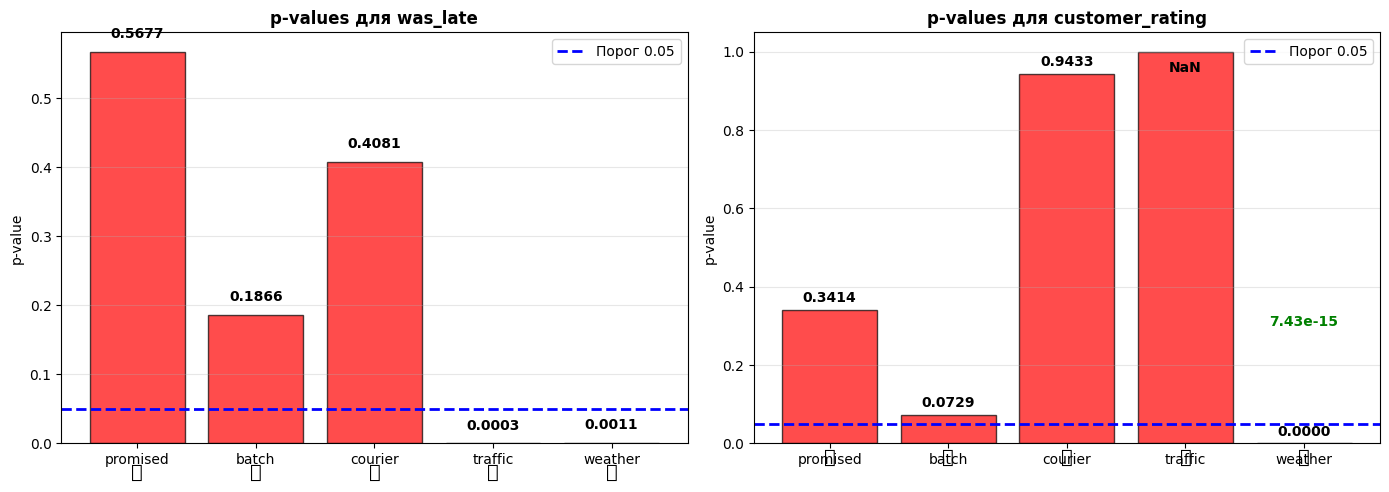

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Данные
tests = ['promised', 'batch', 'courier', 'traffic', 'weather']
p_late = [0.5677, 0.1866, 0.4081, 0.0003, 0.0011]
p_rating = [0.3414, 0.0729, 0.9433, float('nan'), 7.43e-15]

# График 1: p-values для was_late
colors_late = ['red' if p > 0.05 else 'green' for p in p_late]
bars1 = axes[0].bar(tests, p_late, color=colors_late, edgecolor='black', alpha=0.7)
axes[0].axhline(y=0.05, color='blue', linestyle='--', linewidth=2, label='Порог 0.05')
axes[0].set_ylabel('p-value')
axes[0].set_title('p-values для was_late', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(p_late):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    axes[0].text(i, -0.05, '✅' if v < 0.05 else '❌', ha='center', fontsize=14)

# График 2: p-values для customer_rating (логарифмическая шкала)
p_rating_log = [0.3414, 0.0729, 0.9433, 1.0, 7.43e-15]
colors_rating = ['red' if p > 0.05 else 'green' for p in p_rating_log]
bars2 = axes[1].bar(tests, p_rating_log, color=colors_rating, edgecolor='black', alpha=0.7)
axes[1].axhline(y=0.05, color='blue', linestyle='--', linewidth=2, label='Порог 0.05')
axes[1].set_ylabel('p-value')
axes[1].set_title('p-values для customer_rating', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(p_rating_log):
    if v == 1.0:
        axes[1].text(i, v - 0.05, 'NaN', ha='center', fontweight='bold')
    else:
        axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
    axes[1].text(i, -0.05, '✅' if v < 0.05 else '❌', ha='center', fontsize=14)

# Специальная подпись для weather
axes[1].text(4, 0.3, '7.43e-15', ha='center', fontweight='bold', fontsize=10, color='green')

plt.tight_layout()
plt.show()

### Ключевые выводы:

1. **promised_delivery_minutes — НЕ РЕШЕНИЕ**  
   Увеличение обещанного времени не снижает опоздания (p=0.568) и не улучшает рейтинг (p=0.341).  
   **Рекомендация:** Сфокусироваться на сокращении реального времени доставки.

2. **batch_size — НЕ КРИТИЧЕН**  
   Статистически значимой разницы между batch=1 и batch=2-4 нет (p=0.187).  
   **Рекомендация:** Ограничить batch_size до 2 как превентивную меру.

3. **Тип курьера — НЕ КЛЮЧЕВОЙ ФАКТОР**  
   Автомобили статистически не лучше других типов (p=0.408).  
   **Рекомендация:** Продолжить мониторинг, но не делать радикальных изменений.

4. **Пробки — КРИТИЧЕСКИ ВАЖНЫ**  
   Высокий уровень пробок сильно увеличивает опоздания (p=0.0003).  
   **Рекомендация:**  
   - Внедрить динамический promised с учетом пробок  
   - При severe пробках увеличивать promised на 15-20 минут

5. **Погода — САМЫЙ ВАЖНЫЙ ФАКТОР**  
   Плохая погода влияет и на опоздания (p=0.001), и на рейтинг (p=7.4e-15).  
   **Рекомендация:**  
   - Внедрить динамический promised с учетом погоды  
   - В дождь/бурю увеличивать promised на 10-20 минут  
   - Рассмотреть бонусы для курьеров в плохую погоду

---

### ИТОГОВЫЕ РЕКОМЕНДАЦИИ:

1. **Внедрить динамический promised** с учетом пробок и погоды
2. **Сфокусироваться на сокращении actual_delivery_minutes**
3. **Ограничить batch_size до 2** (превентивная мера)
4. **Ввести бонусы для курьеров** в плохую погоду и часы пик
5. **В бурю временно отключать доставку** или предупреждать о задержках